In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [33]:
path = "data/merged.csv"
merged = pd.read_csv(path, parse_dates=["date"])

In [34]:
merged.head()

,date,price,Conventional Oil,Non-Conventional Oil,prod_change_conventional,price_change,price_lag_6,price_lag_12,prod_change
0,2007-01-01,60.85,2707743.4,5604533.2,NaN,NaN,NaN,NaN,NaN
1,2007-02-01,57.35,2450594.2,5414892.8,-257149.2,-3.50,NaN,NaN,-189640.4
2,2007-03-01,61.97,2703836.8,6082110.5,253242.6,4.62,NaN,NaN,667217.7
3,2007-05-01,64.43,2614545.2,5460600.2,-89291.6,2.46,NaN,NaN,-621510.3
4,2007-06-01,65.09,2493203.4,5116667.3,-121341.8,0.66,NaN,NaN,-343932.9


In [35]:
merged.tail()

,date,price,Conventional Oil,Non-Conventional Oil,prod_change_conventional,price_change,price_lag_6,price_lag_12,prod_change
159,2025-08-01,68.39,3183810.5,17662799.8,18743.9,1.75,70.41,74.36,-434845.5
160,2025-09-01,64.36,3062725.8,17030025.6,-121084.7,-4.03,69.81,80.90,-632774.2
161,2025-10-01,62.59,3211750.9,17172423.0,149025.1,-1.77,72.44,84.54,142397.4
162,2025-12-01,59.47,3246489.3,18460827.5,34738.4,-3.12,71.61,80.70,1288404.5
163,2026-01-01,57.26,3240700.9,17518453.6,-5788.4,-2.21,60.59,84.70,-942373.9


## Linear Regression

In [36]:
merged["time"] = range(len(merged))
x = merged[["price", "time"]]
y = merged["Non-Conventional Oil"]


In [37]:
x.head()

,price,time
0,60.85,0
1,57.35,1
2,61.97,2
3,64.43,3
4,65.09,4


In [38]:
y.head()

0    5604533.2
1    5414892.8
2    6082110.5
3    5460600.2
4    5116667.3
Name: Non-Conventional Oil, dtype: float64

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [41]:
merged["predicted"] = model.predict(x)

In [42]:
print("Price Coefficient: ", model.coef_[0])

Price Coefficient:  -7280.61391143108


In [43]:
print("Time Coefficient: ", model.coef_[1])

Time Coefficient:  76658.94275108668


In [44]:
print("intercept:", model.intercept_)

intercept: 5886028.7588751195


In [45]:
print("R^2 score:", model.score(x_test, y_test)) 

R^2 score: 0.9449270695827703


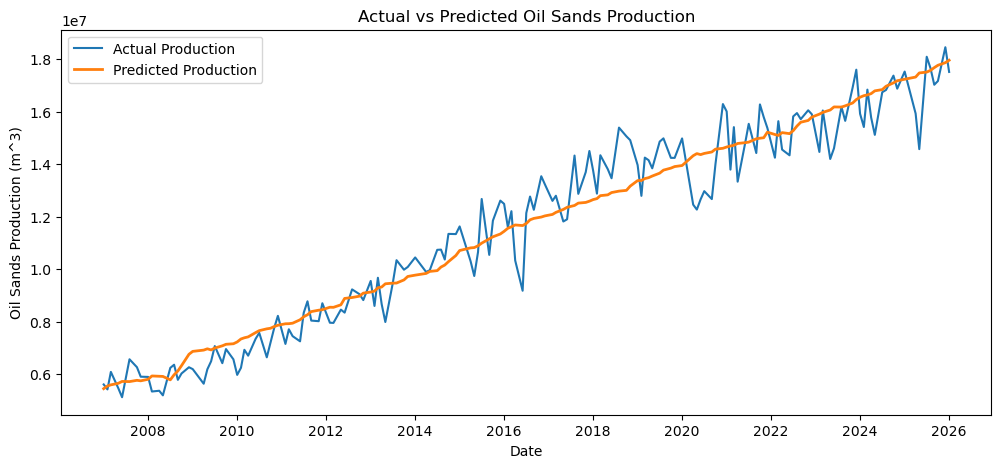

<Figure size 640x480 with 0 Axes>

In [46]:
plt.figure(figsize=(12,5))

plt.plot(merged["date"], merged["Non-Conventional Oil"], label="Actual Production")
plt.plot(merged["date"],merged["predicted"], label="Predicted Production", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Oil Sands Production (m^3)")
plt.title("Actual vs Predicted Oil Sands Production")

plt.legend()

plt.show()
plt.savefig("figures/regression_actual_vs_predicted.png")

In [74]:
merged_clean = merged.dropna()
merged_clean.to_csv("data/final_merged_dataset.csv", index=False)

In [75]:
x_lag = merged_clean[["price_lag_12", "time"]]
y_lag = merged_clean["Non-Conventional Oil"]

In [76]:
X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(x_lag, y_lag, test_size=0.2, random_state=42)

In [77]:
model_lag = LinearRegression()
model.fit(X_train_lag, y_train_lag)

LinearRegression()

In [78]:
print("R^2 score:", model.score(X_test_lag, y_test_lag))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R^2 score: 0.9055943494649022
Coefficients: [-9080.73833278 77647.88627166]
Intercept: 5984312.5358559145


In [80]:
merged_clean.loc[:, "predicted_lag_model"] = model.predict(x_lag)

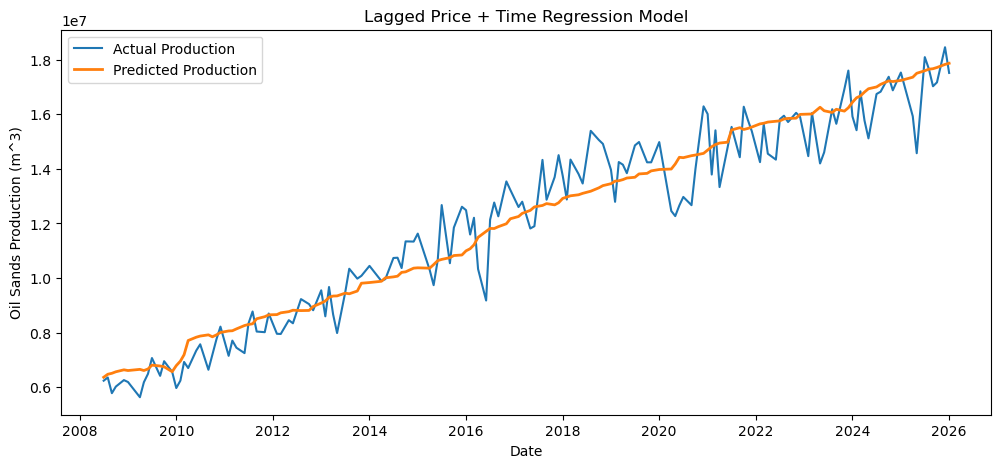

In [86]:
plt.figure(figsize=(12,5))
plt.plot(merged_clean["date"], merged_clean["Non-Conventional Oil"], label="Actual Production")
plt.plot(merged_clean["date"],merged_clean["predicted_lag_model"],label="Predicted Production",linewidth=2)
plt.xlabel("Date")
plt.ylabel("Oil Sands Production (m^3)")
plt.title("Lagged Price + Time Regression Model")
plt.legend()
plt.show()